In [1]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.figsize"] = (10, 6)

# Configuration
INPUT_FILE = Path("llama_topics_v2.json")
FIG_DIR = Path("figures")  # directory for saving generated figures
TOP_N = 20  # number of top elements to analyze or visualize

FIG_DIR.mkdir(exist_ok=True)

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Cannot find {INPUT_FILE.resolve()}")

# Helper functions
def extract_json(text):
    """Clean and parse JSON content from text strings."""
    if isinstance(text, dict):
        return text
    if not isinstance(text, str):
        return {}

    # Strip markdown code fences
    text = re.sub(r"^```(?:json)?\s*", "", text.strip(), flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)

    try:
        return json.loads(text)
    except Exception:
        # Fallback: search for the first JSON object in the text
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except Exception:
                pass
    return {}

def process_item(item):
    """Convert a raw data item into a structured dictionary."""
    analysis = extract_json(item.get("topic_analysis", {}))

    # Parse the publication year safely
    year_raw = item.get("year")
    try:
        year = int(str(year_raw)[:4])
    except (ValueError, TypeError):
        year = np.nan

    return {
        "id": item.get("id"),
        "title": item.get("title", ""),
        "year": year,
        "classification_version": item.get("classification_version", ""),
        "is_covid19": bool(analysis.get("is_covid19", False)),
        "main_topic": analysis.get("main_topic", ""),
        "research_field": analysis.get("research_field", ""),
        "methodology": analysis.get("methodology", []),
        "application_domain": analysis.get("application_domain", ""),
        "keywords": analysis.get("keywords", []),
        "json_valid": analysis.get("json_valid", True),
        "temporal_violation": analysis.get("temporal_violation", False)
    }

# Data loading and processing
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    raw_results = json.load(f)

print(f"Total records: {len(raw_results)}")

records = [process_item(item) for item in raw_results]
df = pd.DataFrame(records)

print(f"DataFrame shape: {df.shape}")
df.head()

# Time axis: 5-year periods. The final "2025" bucket is the still-open tail
# of the last span (2026 excluded).
TIME_PERIODS = [
    ("1996-00", 1996, 2000),
    ("2001-05", 2001, 2005),
    ("2006-10", 2006, 2010),
    ("2011-15", 2011, 2015),
    ("2016-20", 2016, 2020),
    ("2021-25", 2021, 2025),
]

PERIOD_LABELS = [label for label, _, _ in TIME_PERIODS]

def to_period(year):
    """Map a year to its 5-year span label."""
    if pd.isna(year):
        return np.nan
    year = int(year)
    for label, start, end in TIME_PERIODS:
        if start <= year <= end:
            return label
    return np.nan

def valid_counts(series, n=TOP_N):
    """Count non-empty values, excluding missing or whitespace entries."""
    return series.fillna("").str.strip().replace("", np.nan).dropna().value_counts().head(n)

def barh_plot(series, title, filename, palette="crest"):
    """Horizontal bar chart with data labels, saved to FIG_DIR."""
    series = series.sort_values()
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = sns.color_palette(palette, len(series))
    ax.barh(series.index, series.values, color=colors)
    for i, v in enumerate(series.values):
        ax.text(v + max(series.values) * 0.015, i, f"{v:,}", va="center", fontsize=9)
    ax.set_xlabel("Number of papers")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.invert_yaxis()
    sns.despine()
    fig.savefig(FIG_DIR / filename, dpi=200)
    plt.show()

Total records: 10426
DataFrame shape: (10426, 12)


In [2]:
df["period"] = df["year"].map(to_period)
print("Periods:", PERIOD_LABELS)
print("Papers per period:")
print(df.groupby("period").size().reindex(PERIOD_LABELS, fill_value=0).to_string())

# Drop empty 5-year spans from the time axes so shares stay well-defined
period_sizes = df.groupby("period").size()
PERIODS_WITH_DATA = [p for p in PERIOD_LABELS if period_sizes.get(p, 0) > 0]
print("Periods with data:", PERIODS_WITH_DATA)
display(df.head())

Periods: ['1996-00', '2001-05', '2006-10', '2011-15', '2016-20', '2021-25']
Papers per period:
period
1996-00      92
2001-05     427
2006-10    1085
2011-15    1958
2016-20    2689
2021-25    3712
Periods with data: ['1996-00', '2001-05', '2006-10', '2011-15', '2016-20', '2021-25']


,id,title,year,classification_version,is_covid19,main_topic,research_field,methodology,application_domain,keywords,json_valid,temporal_violation,period
0,https://openalex.org/W2151097880,Spatial agent‐based modelling,2006,v2.0,False,Spatial modeling,Computer Science,"[Agent-Based Modeling, Discrete-Event Simulati...",Geographic Information Systems,"[Data Management and Algorithms, Geographic In...",True,False,2006-10
1,https://openalex.org/W2113172691,Environment Mediated Multi Agent Simulation To...,2008,v2.0,False,Simulation Techniques and Applications,Computer Science,"[Agent-Based Modeling, Network Analysis]",Environment Mediated Multi Agent Simulation Tools,[],True,False,2006-10
2,https://openalex.org/W1970054845,An Agent-Based Middleware for the Design of Ac...,2010,v2.0,False,Activity-Aware Systems,Computer Science,"[Agent-Based Modeling, Middleware]",Business Process Management,"[Business Process Modeling, Activity Recogniti...",True,False,2006-10
3,https://openalex.org/W4414426742,Experiencing the Effects of Organ Donation Pol...,2025,v2.0,False,Organ Donation and Transplantation,Public Health,[Agent-Based Modeling],Organ Donation,[],True,False,2021-25
4,https://openalex.org/W2139079339,Modeling and simulation of manufacturing syste...,2002,v2.0,False,Manufacturing Systems Optimization,Computer Science,"[Agent-Based Modeling, Simulation]",Manufacturing,"[Scheduling and Optimization Algorithms, Assem...",True,False,2001-05


In [3]:
# Data quality summary
print("=" * 60)
print("DATA QUALITY")
print("=" * 60)
print(f"Total papers: {len(df):,}")
print(f"Unique IDs:   {df['id'].nunique():,}")
print(f"Missing year: {df['year'].isna().sum()}")
for col in ["main_topic", "research_field", "application_domain"]:
    print(f"Missing {col}: {df[col].fillna('').str.strip().eq('').sum()}")
print(f"Invalid JSON: {(~df['json_valid']).sum()}")
print(f"Temporal violations: {df['temporal_violation'].sum()}")

DATA QUALITY
Total papers: 10,426
Unique IDs:   10,426
Missing year: 0
Missing main_topic: 292
Missing research_field: 292
Missing application_domain: 384
Invalid JSON: 292
Temporal violations: 0


In [4]:
# COVID-19 temporal validation: no pre-2020 paper may be COVID-19
COVID_START_YEAR = 2020
pre_2020 = df[(df["year"] < COVID_START_YEAR) & df["is_covid19"]]
print(f"Pre-2020 COVID-19 papers: {len(pre_2020)}")
if len(pre_2020) == 0:
    print("PASS: No pre-2020 paper is classified as COVID-19.")
else:
    print("FAIL: Temporal violations detected.")
    display(pre_2020[["id", "year", "title", "main_topic", "application_domain"]].head(50))

Pre-2020 COVID-19 papers: 0
PASS: No pre-2020 paper is classified as COVID-19.


In [5]:
# COVID-19 terminology contamination check on topic fields
COVID_PATTERN = re.compile(
    r"\bcovid[- ]?19\b|\bcovid19\b|\bsars[- ]cov[- ]?2\b|\bsarscov2\b"
    r"|\b2019[- ]ncov\b|\bcoronavirus disease 2019\b",
    flags=re.IGNORECASE,
)

for col, label in [("main_topic", "MAIN TOPIC"), ("application_domain", "APPLICATION DOMAIN")]:
    hits = df[df[col].fillna("").str.contains(COVID_PATTERN, na=False)]
    print(f"{label} COVID-19 mentions: {len(hits)}")
    if len(hits):
        display(hits[["year", "title", "main_topic", "research_field",
                      "application_domain", "is_covid19"]].head(30))
    else:
        print(f"PASS: No COVID-19 terminology in {col}.")

MAIN TOPIC COVID-19 mentions: 0
PASS: No COVID-19 terminology in main_topic.
APPLICATION DOMAIN COVID-19 mentions: 39


,year,title,main_topic,research_field,application_domain,is_covid19
681,2022,An LBS and agent-based simulator for Covid-19 ...,Mobility and Location-Based Analysis,Computer Science,COVID-19,True
1388,2021,FPGA-accelerated Agent-Based Simulation for CO...,Epidemic modeling,Computer Science,COVID-19,True
1797,2021,Agent-based Modeling as a Tool for Predicting ...,Pandemic Modeling,Epidemiology,COVID-19,True
2177,2024,코로나바이러스감염증-19 접촉추적격리 정책 국제 비교 및 정책 효과 시뮬레이션 연구,Contact tracing and isolation policies,Epidemiology,COVID-19,True
3238,2022,Build an Agent-Based Model for COVID-19 Effect...,Epidemic modeling,Public Health,COVID-19,True
3323,2021,Evaluation of undetected cases during the COVI...,Epidemiological modeling,Epidemiology,COVID-19,True
3578,2025,Multi-scale phylodynamic modelling of rapid pu...,Phylodynamic modeling,Epidemiology,SARS-CoV-2,True
4241,2021,An interaction-oriented multi-agent SIR model ...,Disease Transmission Modeling,Epidemiology,SARS-CoV-2,True
4506,2021,Spatially resolved simulations of the spread o...,Spatial epidemiology,Epidemiology,COVID-19,True
4846,2023,The effect of variation of individual infectio...,Household Transmission Dynamics,Epidemiology,SARS-CoV-2,True


,count
period,
1996-00,0
2001-05,0
2006-10,0
2011-15,0
2016-20,40
2021-25,437


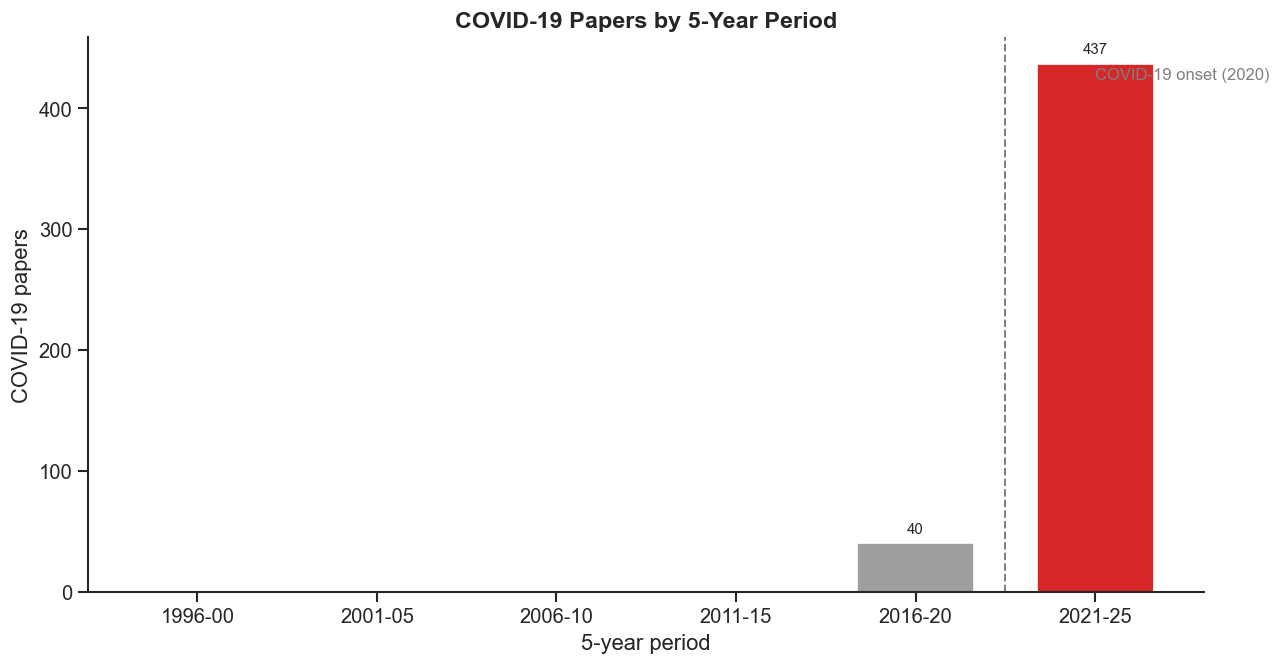

In [6]:
# COVID-19 papers by 5-year period
covid_by_period = (
    df[df["is_covid19"]].groupby("period").size()
    .reindex(PERIODS_WITH_DATA, fill_value=0)
)
display(covid_by_period.to_frame("count"))

onset_x = PERIODS_WITH_DATA.index("2021-25") - 0.5
x = np.arange(len(PERIODS_WITH_DATA))
colors = ["#d62728" if xi >= onset_x + 0.5 else "#9e9e9e" for xi in x]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x, covid_by_period.values, color=colors, width=0.65)
ax.axvline(onset_x, linestyle="--", linewidth=1.2, color="gray")
ax.text(onset_x + 0.5, covid_by_period.max() * 0.97, "COVID-19 onset (2020)",
        fontsize=10, color="gray")
for xi, v in enumerate(covid_by_period.values):
    if v:
        ax.text(xi, v + covid_by_period.max() * 0.02, f"{v}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(PERIODS_WITH_DATA)
ax.set_xlabel("5-year period")
ax.set_ylabel("COVID-19 papers")
ax.set_title("COVID-19 Papers by 5-Year Period", fontsize=14, fontweight="bold")
sns.despine()
fig.savefig(FIG_DIR / "covid_by_period.png", dpi=200)
plt.show()

,count
main_topic,
Social Network Analysis,361
Urban Planning,217
Transportation Planning and Optimization,205
Population Dynamics,185
Epidemiology,136
Epidemiological modeling,133
Evacuation and Crowd Dynamics,125
Agent-based modeling,116
Supply Chain Management,113


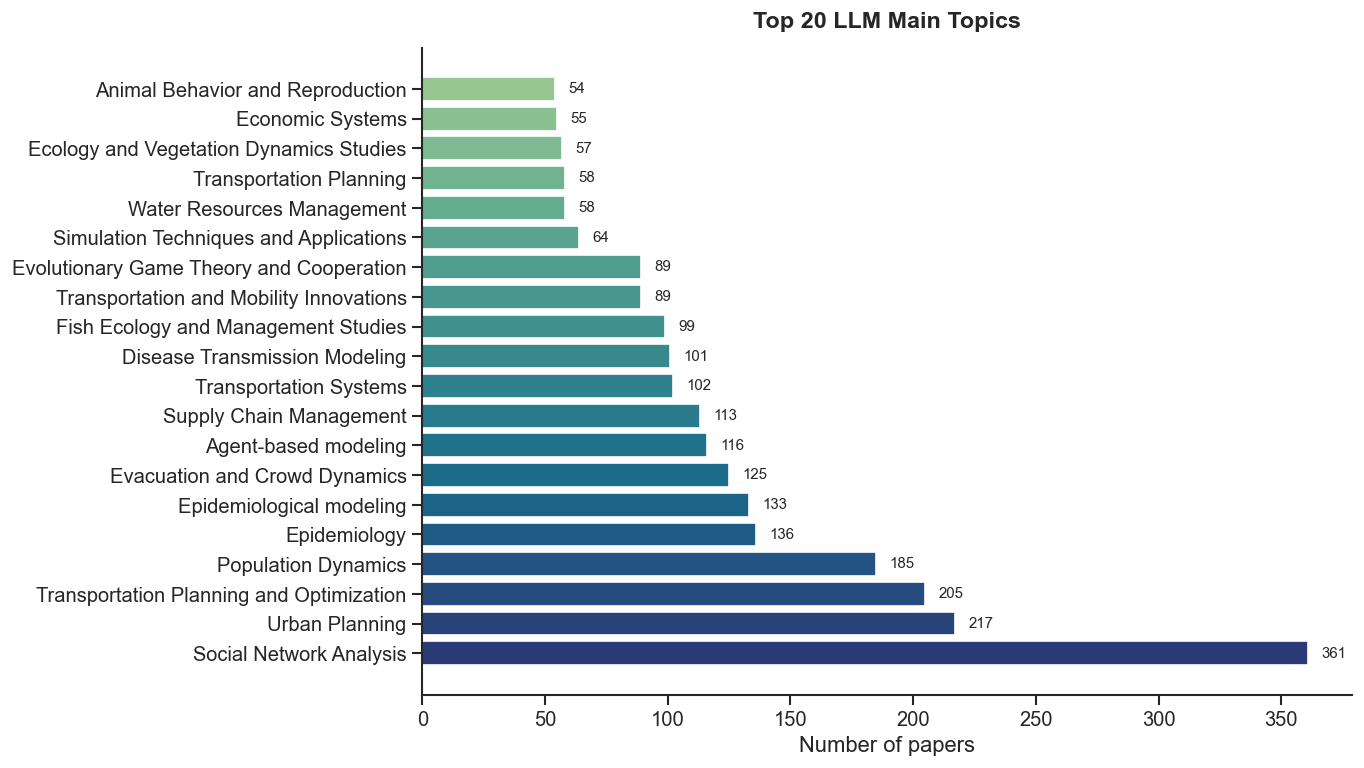

In [7]:
# Top main topics (empty/unknown values excluded)
topic_counts = valid_counts(df["main_topic"])
display(topic_counts.to_frame("count"))
barh_plot(topic_counts, f"Top {TOP_N} LLM Main Topics", "top_topics.png")

,count
research_field,
Computer Science,2897
Ecology,1098
Epidemiology,881
Economics,835
Sociology,651
Transportation Engineering,384
Public Health,275
Biology,162
Urban Planning,131


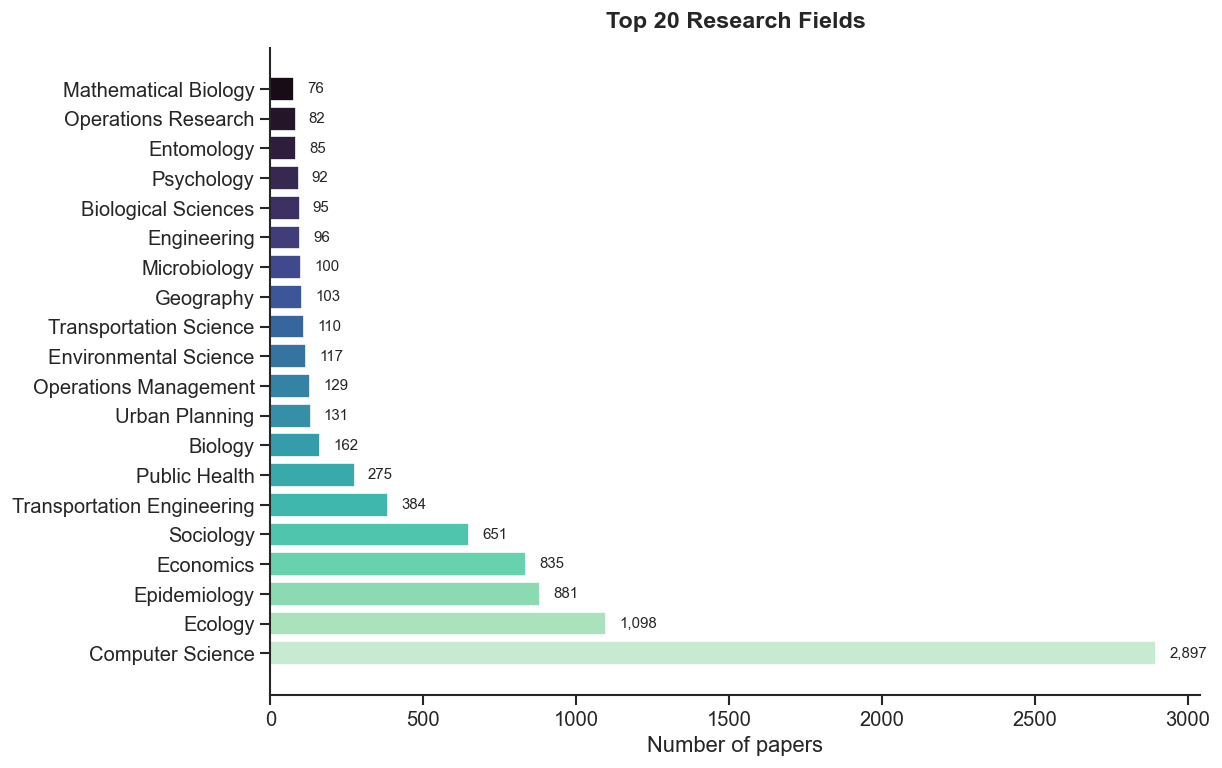

In [8]:
# Top research fields (empty/unknown values excluded)
field_counts = valid_counts(df["research_field"])
display(field_counts.to_frame("count"))
barh_plot(field_counts, f"Top {TOP_N} Research Fields", "top_fields.png", palette="mako")

,count
application_domain,
Urban Planning,466
Public Health,464
Urban Population,209
Transportation Planning and Optimization,164
Wildlife Ecology and Conservation,105
Urban Transport and Accessibility,90
Financial Markets,88
Smart Grid Energy Management,86
Urban Transportation,86


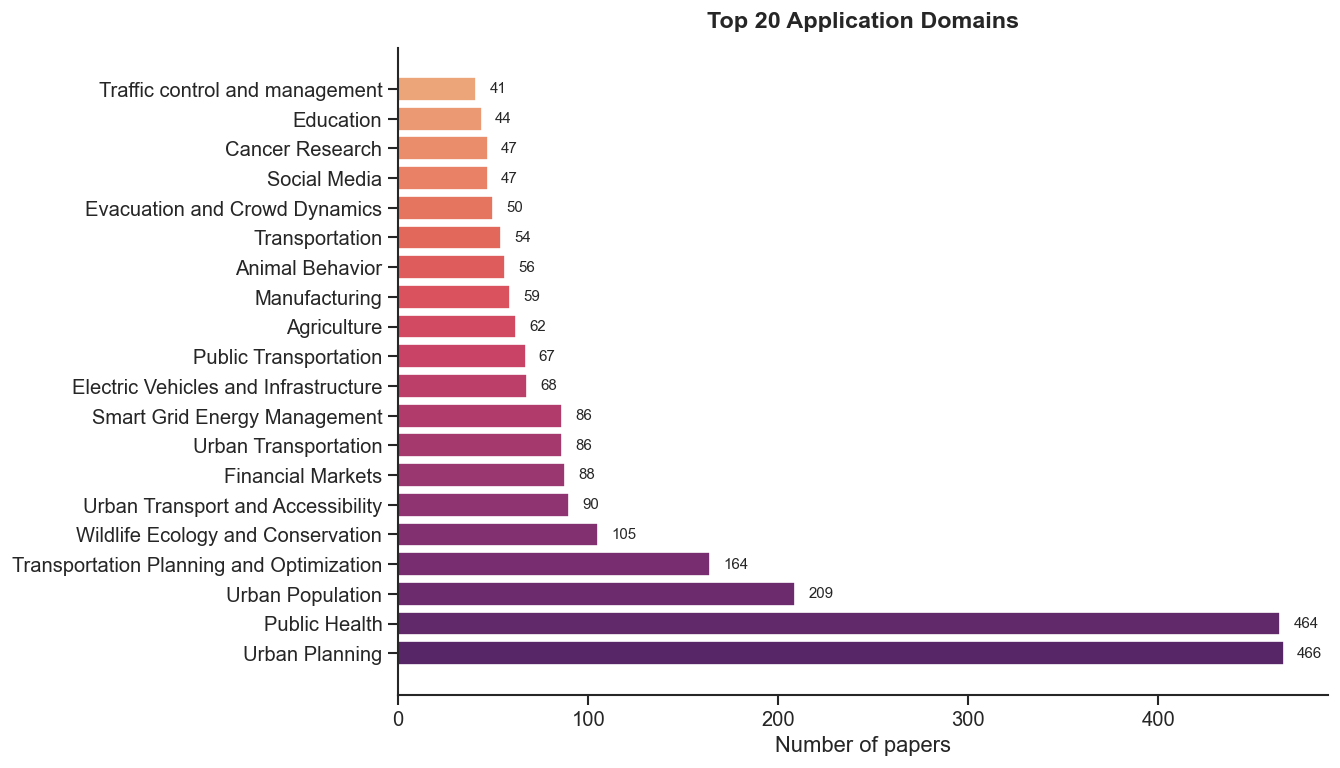

In [9]:
# Top application domains (empty/unknown values excluded)
domain_counts = valid_counts(df["application_domain"])
display(domain_counts.to_frame("count"))
barh_plot(domain_counts, f"Top {TOP_N} Application Domains", "top_domains.png", palette="flare")

Proportion trend plot saved to: figures\application_domain_trends_proportion.png


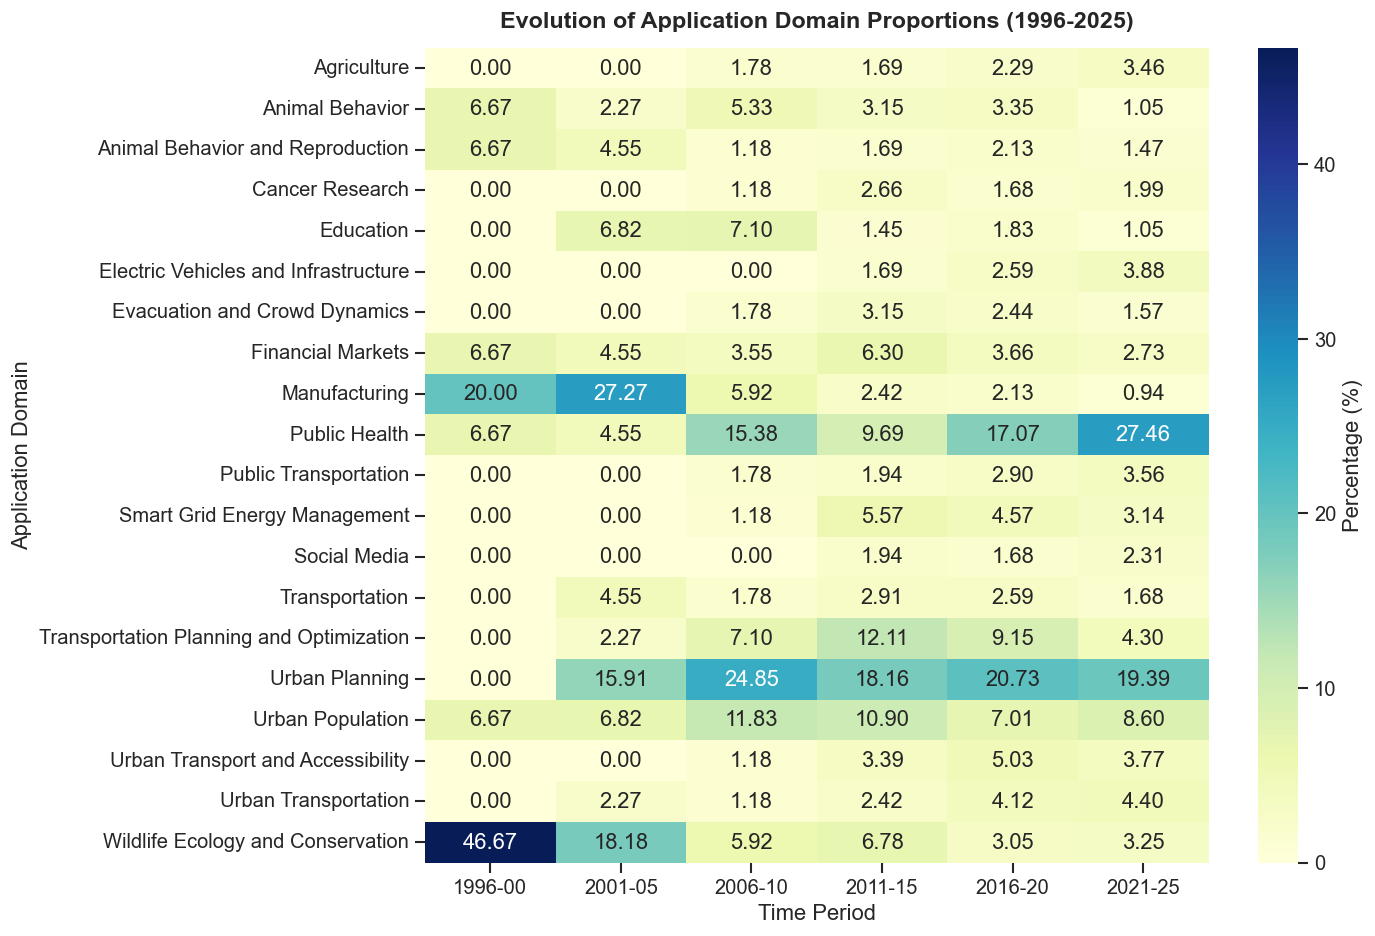

In [10]:
# Application domain trends (proportion / percentage)
def plot_application_domain_trends_proportion(df, output_dir):
    """Plot the percentage distribution of top application domains over time periods."""

    df["period"] = df["year"].apply(to_period)

    df_valid = df[df["period"].notna()].copy()
    df_valid = df_valid[df_valid["application_domain"].notna() & (df_valid["application_domain"].str.strip() != "")].copy()
    top_domains = df_valid["application_domain"].value_counts().nlargest(TOP_N).index
    df_filtered = df_valid[df_valid["application_domain"].isin(top_domains)].copy()

    trend_counts = pd.crosstab(df_filtered["period"], df_filtered["application_domain"])
    trend_counts = trend_counts.reindex(PERIOD_LABELS).fillna(0)

    # Row-wise percentages per time period
    trend_prop = trend_counts.div(trend_counts.sum(axis=1), axis=0).fillna(0) * 100

    plt.figure(figsize=(12, 8))
    sns.heatmap(trend_prop.T, annot=True, fmt=".2f", cmap="YlGnBu",
                cbar_kws={"label": "Percentage (%)"})

    plt.title("Evolution of Application Domain Proportions (1996-2025)", fontsize=14, fontweight="bold", pad=12)
    plt.xlabel("Time Period")
    plt.ylabel("Application Domain")
    plt.tight_layout()

    save_path = output_dir / "application_domain_trends_proportion.png"
    plt.savefig(save_path, dpi=200)
    print(f"Proportion trend plot saved to: {save_path}")
    plt.show()

plot_application_domain_trends_proportion(df, FIG_DIR)

main_topic,Social Network Analysis,Urban Planning,Transportation Planning and Optimization,Population Dynamics,Epidemiology,Epidemiological modeling,Evacuation and Crowd Dynamics,Agent-based modeling
period,,,,,,,,
1996-00,2,2,0,12,0,0,0,1
2001-05,6,4,3,25,5,0,0,6
2006-10,33,15,10,22,28,4,9,8
2011-15,101,43,29,33,25,7,25,28
2016-20,84,52,89,39,35,23,44,31
2021-25,117,87,70,44,37,93,39,39


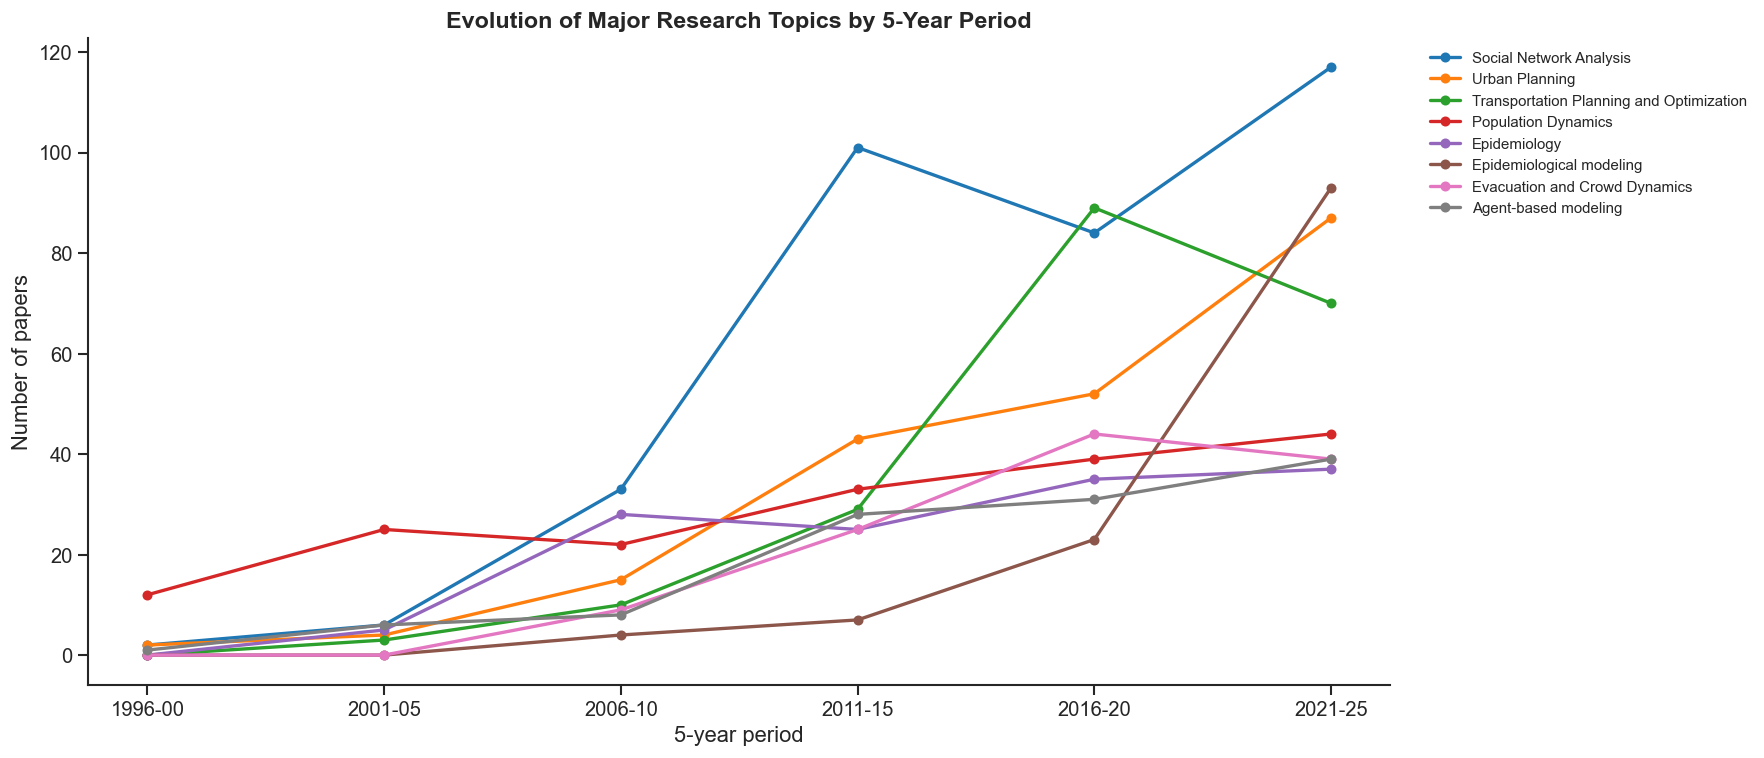

In [11]:
# Evolution of the top 8 research topics by 5-year period
top_topics = valid_counts(df["main_topic"], 8).index
topic_period = (
    df[df["main_topic"].isin(top_topics) & df["period"].notna()]
    .groupby(["period", "main_topic"]).size().unstack(fill_value=0)
)
topic_period = topic_period.reindex(PERIODS_WITH_DATA, fill_value=0)
topic_period = topic_period[top_topics.intersection(topic_period.columns)]
display(topic_period)

x = np.arange(len(topic_period.index))
fig, ax = plt.subplots(figsize=(14, 7))
palette = sns.color_palette("tab10", len(topic_period.columns))
for topic, color in zip(topic_period.columns, palette):
    ax.plot(x, topic_period[topic].values, label=topic,
            linewidth=2, marker="o", markersize=5, color=color)
ax.set_xticks(x)
ax.set_xticklabels(topic_period.index)
ax.set_xlabel("5-year period")
ax.set_ylabel("Number of papers")
ax.set_title("Evolution of Major Research Topics by 5-Year Period",
             fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
sns.despine()
fig.savefig(FIG_DIR / "topic_evolution.png", dpi=200)
plt.show()

period,1996-00,2001-05,2006-10,2011-15,2016-20,2021-25
main_topic,,,,,,
Social Network Analysis,2.2,1.4,3.0,5.2,3.1,3.2
Urban Planning,2.2,0.9,1.4,2.2,1.9,2.3
Transportation Planning and Optimization,0.0,0.7,0.9,1.5,3.3,1.9
Population Dynamics,13.0,5.9,2.0,1.7,1.5,1.2
Epidemiology,0.0,1.2,2.6,1.3,1.3,1.0
Epidemiological modeling,0.0,0.0,0.4,0.4,0.9,2.5
Evacuation and Crowd Dynamics,0.0,0.0,0.8,1.3,1.6,1.1
Agent-based modeling,1.1,1.4,0.7,1.4,1.2,1.1
Supply Chain Management,0.0,1.9,1.5,0.9,1.2,1.1


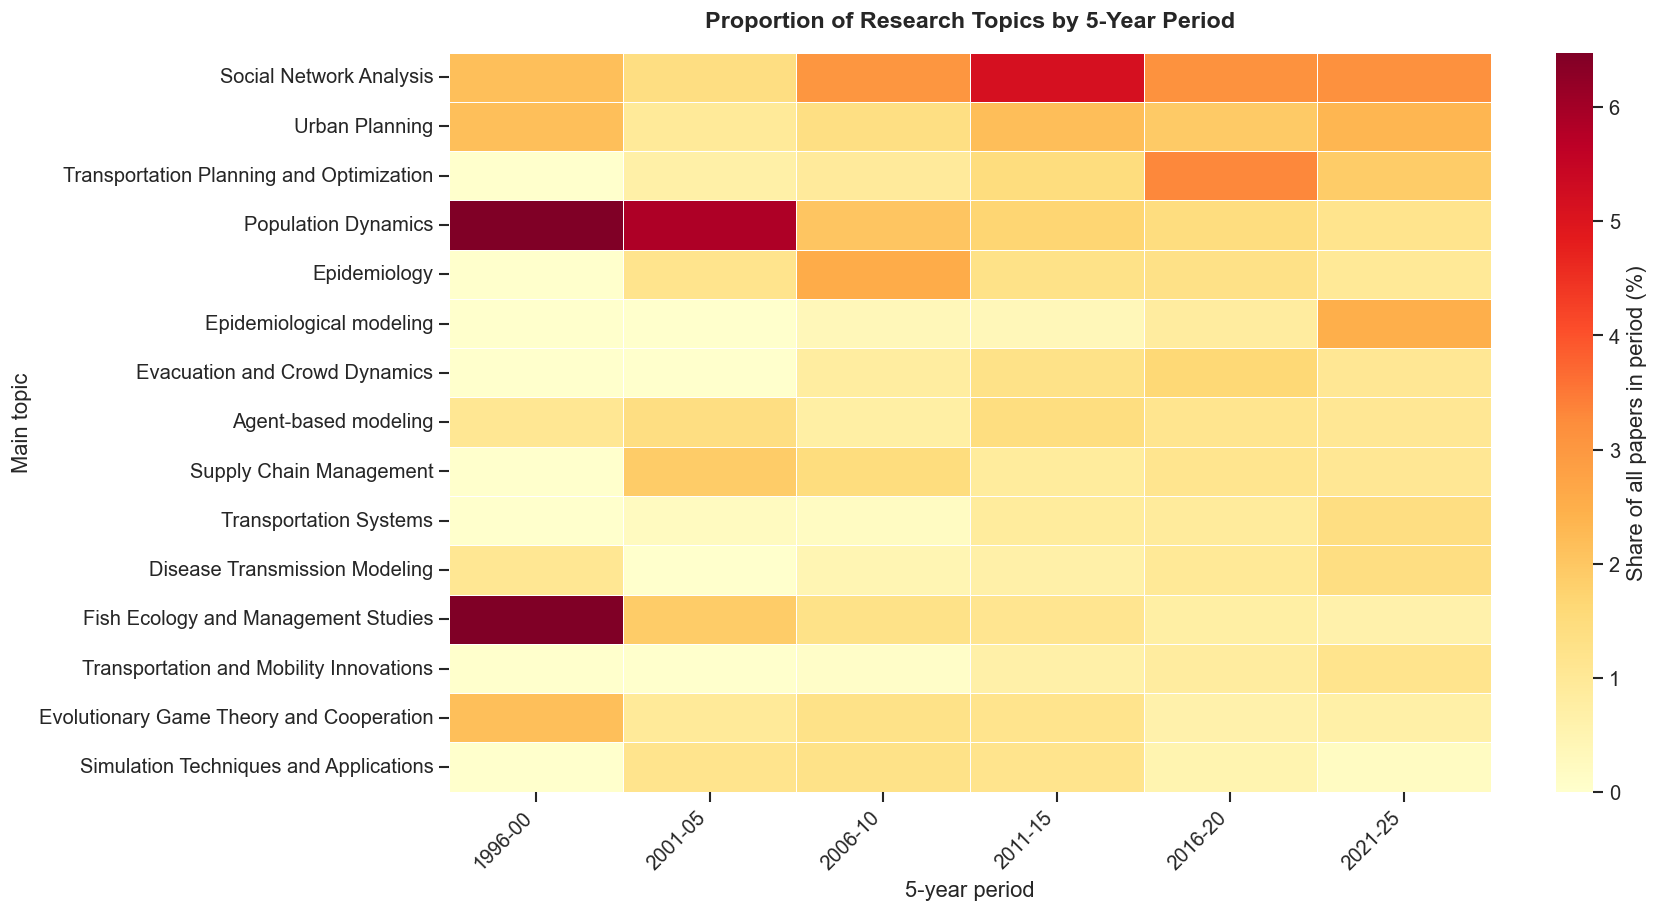

In [12]:
# Main topic x 5-year period proportion heatmap (top 15 topics)
top_topics = valid_counts(df["main_topic"], 15).index
topic_period_counts = (
    df[df["main_topic"].isin(top_topics) & df["period"].notna()]
    .groupby(["main_topic", "period"]).size().unstack(fill_value=0)
)
topic_period_counts = topic_period_counts.loc[top_topics.intersection(topic_period_counts.index)]
topic_period_counts = topic_period_counts.reindex(columns=PERIODS_WITH_DATA, fill_value=0)

period_total = df[df["period"].notna()].groupby("period").size()
period_total = period_total.reindex(PERIODS_WITH_DATA)
topic_period_proportion = topic_period_counts.div(period_total, axis=1) * 100
display(topic_period_proportion.round(1))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(topic_period_proportion, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            vmin=0, vmax=np.nanpercentile(topic_period_proportion.values, 98),
            cbar_kws={"label": "Share of all papers in period (%)"}, ax=ax)
ax.set_xlabel("5-year period")
ax.set_ylabel("Main topic")
ax.set_title("Proportion of Research Topics by 5-Year Period",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
fig.savefig(FIG_DIR / "topic_share_heatmap.png", dpi=200)
plt.show()

,count
Agent-based modeling,7656
Simulation,1791
Regression analysis,1401
Network analysis,970
Individual-based modeling,865
Spatial analysis,800
System dynamics,200
Machine learning,140
Agent-based simulation,130
Survey research,109


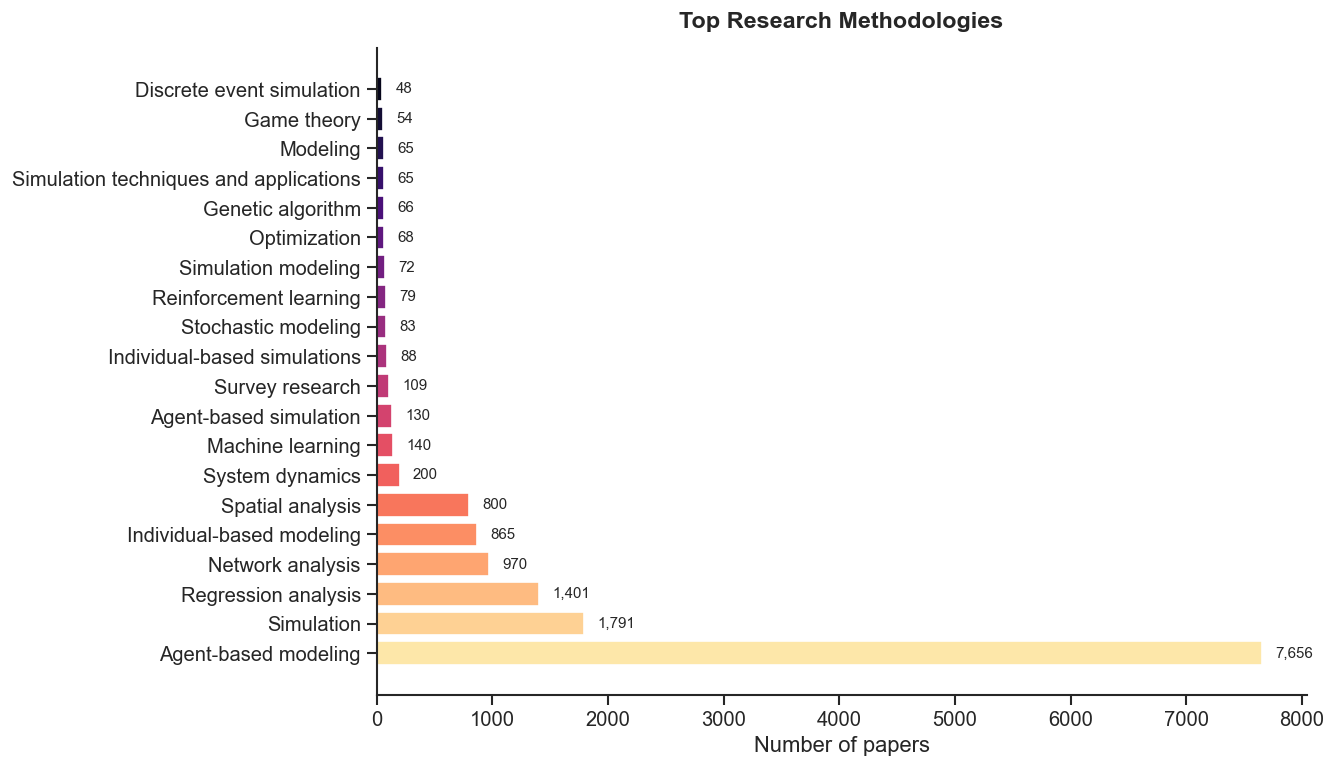

In [13]:
# Top methodologies (case-normalized to merge spelling variants)
def _norm_method(m):
    m = str(m).strip()
    return m[0].upper() + m[1:].lower() if m else m

method_counter = Counter(
    _norm_method(m)
    for methods in df["methodology"] if isinstance(methods, list)
    for m in methods if str(m).strip()
)
method_counts = pd.Series(method_counter).sort_values(ascending=False).head(20)
display(method_counts.to_frame("count"))
barh_plot(method_counts, "Top Research Methodologies", "top_methodologies.png", palette="magma")

period,1996-00,2001-05,2006-10,2011-15,2016-20,2021-25
application_domain,,,,,,
Urban Planning,0.0,1.6,3.9,3.8,5.1,5.0
Public Health,1.1,0.5,2.4,2.0,4.2,7.1
Urban Population,1.1,0.7,1.8,2.3,1.7,2.2
Transportation Planning and Optimization,0.0,0.2,1.1,2.6,2.2,1.1
Wildlife Ecology and Conservation,7.6,1.9,0.9,1.4,0.7,0.8
Urban Transport and Accessibility,0.0,0.0,0.2,0.7,1.2,1.0
Financial Markets,1.1,0.5,0.6,1.3,0.9,0.7
Smart Grid Energy Management,0.0,0.0,0.2,1.2,1.1,0.8
Urban Transportation,0.0,0.2,0.2,0.5,1.0,1.1


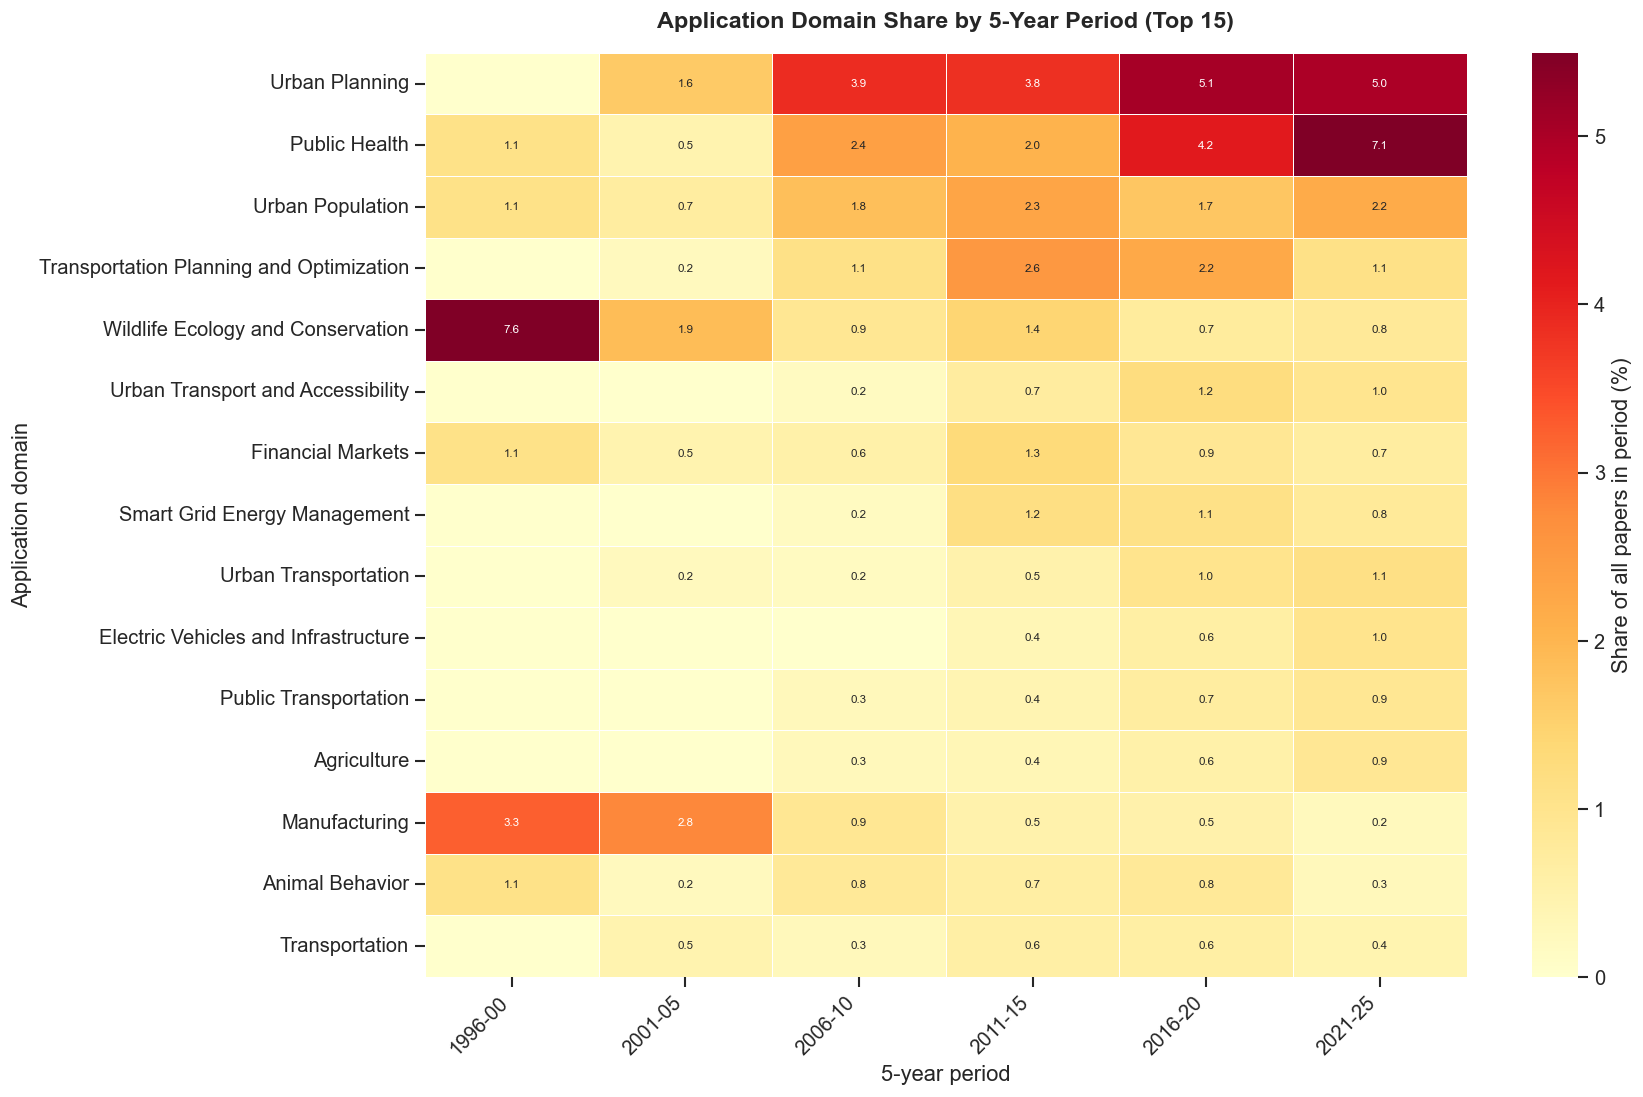

In [14]:
# Application domain x 5-year period proportion heatmap (top 15 domains;
# zero cells left unlabelled to reduce clutter)
top_domains = valid_counts(df["application_domain"], 15).index
domain_period_counts = (
    df[df["application_domain"].isin(top_domains) & df["period"].notna()]
    .groupby(["application_domain", "period"]).size().unstack(fill_value=0)
)
domain_period_counts = domain_period_counts.loc[top_domains.intersection(domain_period_counts.index)]
domain_period_counts = domain_period_counts.reindex(columns=PERIODS_WITH_DATA, fill_value=0)

period_total = df[df["period"].notna()].groupby("period").size()
period_total = period_total.reindex(PERIODS_WITH_DATA)
domain_period_share = domain_period_counts.div(period_total, axis=1) * 100
display(domain_period_share.round(1))

annot = domain_period_share.map(lambda v: f"{v:.1f}" if v > 0 else "")
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(domain_period_share, annot=annot, fmt="", cmap="YlOrRd",
            linewidths=0.3, linecolor="white", annot_kws={"fontsize": 7},
            vmin=0, vmax=np.nanpercentile(domain_period_share.values, 98),
            cbar_kws={"label": "Share of all papers in period (%)"}, ax=ax)
ax.set_xlabel("5-year period")
ax.set_ylabel("Application domain")
ax.set_title("Application Domain Share by 5-Year Period (Top 15)",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
fig.savefig(FIG_DIR / "domain_share_heatmap.png", dpi=200)
plt.show()

application_domain,Urban Planning,Public Health,Urban Population,Transportation Planning and Optimization,Wildlife Ecology and Conservation,Urban Transport and Accessibility,Financial Markets,Smart Grid Energy Management,Urban Transportation,Electric Vehicles and Infrastructure
period,,,,,,,,,,
1996-00,0.0,1.1,1.1,0.0,7.6,0.0,1.1,0.0,0.0,0.0
2001-05,1.6,0.5,0.7,0.2,1.9,0.0,0.5,0.0,0.2,0.0
2006-10,3.9,2.4,1.8,1.1,0.9,0.2,0.6,0.2,0.2,0.0
2011-15,3.8,2.0,2.3,2.6,1.4,0.7,1.3,1.2,0.5,0.4
2016-20,5.1,4.2,1.7,2.2,0.7,1.2,0.9,1.1,1.0,0.6
2021-25,5.0,7.1,2.2,1.1,0.8,1.0,0.7,0.8,1.1,1.0


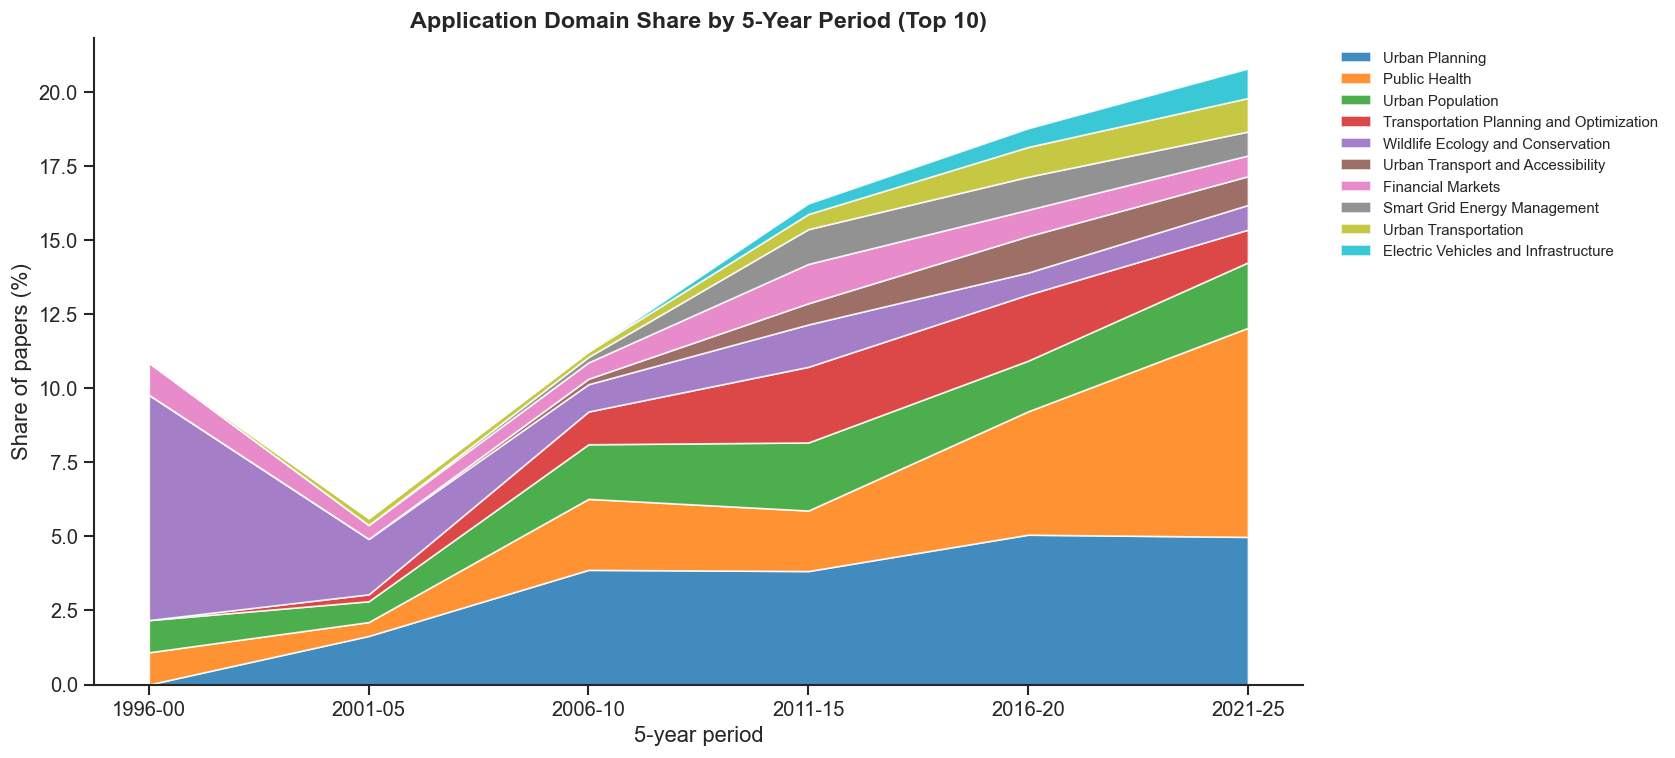

In [15]:
# Stacked area: application domain share by 5-year period (top 10)
top_domains = valid_counts(df["application_domain"], 10).index
domain_period = (
    df[df["application_domain"].isin(top_domains) & df["period"].notna()]
    .groupby(["period", "application_domain"]).size().unstack(fill_value=0)
)
domain_period = domain_period.reindex(PERIODS_WITH_DATA, fill_value=0)
domain_period = domain_period[top_domains.intersection(domain_period.columns)]

# Align period totals to the row index
period_total = df[df["period"].notna()].groupby("period").size()
period_total = period_total.reindex(domain_period.index)
domain_share = domain_period.div(period_total, axis=0) * 100
display(domain_share.round(1))

x = np.arange(len(domain_share.index))
fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette("tab10", len(domain_share.columns))
ax.stackplot(x, [domain_share[c].values for c in domain_share.columns],
             labels=list(domain_share.columns), colors=palette, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(domain_share.index)
ax.set_xlabel("5-year period")
ax.set_ylabel("Share of papers (%)")
ax.set_title("Application Domain Share by 5-Year Period (Top 10)",
             fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)
sns.despine()
fig.savefig(FIG_DIR / "domain_share_stacked.png", dpi=200)
plt.show()

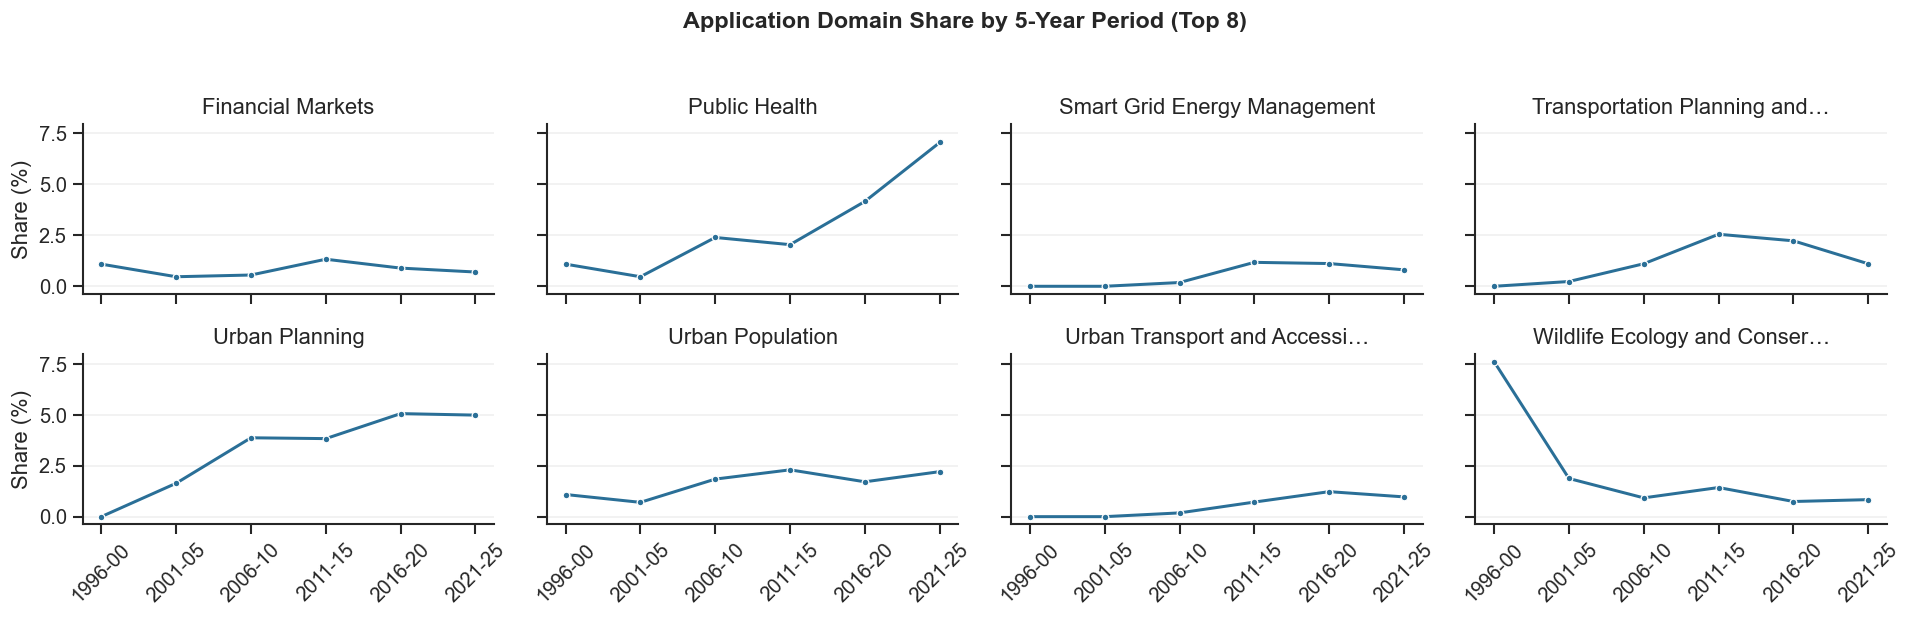

In [16]:
# Small multiples: share trend of the top 8 application domains
def _shorten(name, limit=28):
    name = name or ""
    return name if len(name) <= limit else name[:limit - 1] + "…"

top_domains = valid_counts(df["application_domain"], 8).index
domain_period = (
    df[df["application_domain"].isin(top_domains) & df["period"].notna()]
    .groupby(["application_domain", "period"]).size().unstack(fill_value=0)
)
domain_period = domain_period.reindex(columns=PERIOD_LABELS, fill_value=0)

period_total = df[df["period"].notna()].groupby("period").size()
period_total = period_total.reindex(PERIOD_LABELS, fill_value=0)
domain_share = domain_period.div(period_total, axis=1) * 100

long = domain_share.reset_index().melt(id_vars="application_domain",
                                       var_name="period", value_name="share")
long["domain_short"] = long["application_domain"].map(_shorten)

g = sns.FacetGrid(long, col="domain_short", col_wrap=4,
                  sharey=True, height=2.5, aspect=1.6)
g.map_dataframe(sns.lineplot, x="period", y="share",
                marker="o", markersize=4, linewidth=1.8, color="#2a6f97")
g.set_titles("{col_name}", fontsize=10)
g.set_axis_labels("", "Share (%)")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(axis="y", alpha=0.3)
g.figure.suptitle("Application Domain Share by 5-Year Period (Top 8)",
                  fontsize=14, fontweight="bold", y=1.03)
g.tight_layout()
g.savefig(FIG_DIR / "domain_share_facet.png", dpi=200)
plt.show()